# 3. STFT versus Constant-Q Transform

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-GITHUB-USER/chord-recognition-book/blob/main/notebooks/03_stft_vs_cqt.ipynb)

> **Paper ↔ code.** Section II-B: Fig. 1 (flute vs. piano spectra), the three difficulties (spectral crowding, root isolation, false positives), the STFT (Eq. 5) and the CQT (Eqs. 6–9), Fig. 2 (time–frequency tiling). Functions: `features.cqt`, `features.cqt_center_frequencies`, `features.cqt_window_lengths`, `features.Q_FACTOR`, `plots.plot_tf_tiling`.

In [1]:
# --- Setup: works locally (run from anywhere inside the repository) and on Google Colab ---
import os, sys, pathlib, subprocess

REPO = "YOUR-GITHUB-USER/chord-recognition-book"   # <-- change this after forking

if "google.colab" in sys.modules:
    root = pathlib.Path("/content") / REPO.split("/")[1]
    if not root.exists():
        subprocess.run(["git", "clone", "-q", f"https://github.com/{REPO}.git", str(root)], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(root)], check=True)
else:
    root = pathlib.Path.cwd().resolve()
    while not (root / "chordlab").exists() and root != root.parent:
        root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import IPython.display as ipd

import chordlab
from chordlab import data, features, templates, hmm, evaluate, midi_chords, synth, plots

plt.rcParams["figure.figsize"] = (11, 3.5)
plt.rcParams["figure.dpi"] = 110
print(f"chordlab {chordlab.__version__} loaded from {root}")
print("data folder:", data.data_root())

chordlab 0.1.0 loaded from /home/claude/chord-recognition-book
data folder: /home/claude/chord-recognition-book/data


## 3.1 Fig. 1: a flute is a line, a piano is a comb

A note is not one frequency. Most instruments produce a **fundamental** $f_0$ plus **overtones** at (approximately) integer multiples $2f_0, 3f_0, \dots$. The paper's Fig. 1 contrasts a flute (energy concentrated at $f_0$) with a piano (many strong overtones). Let us reproduce it with the synthetic timbres.

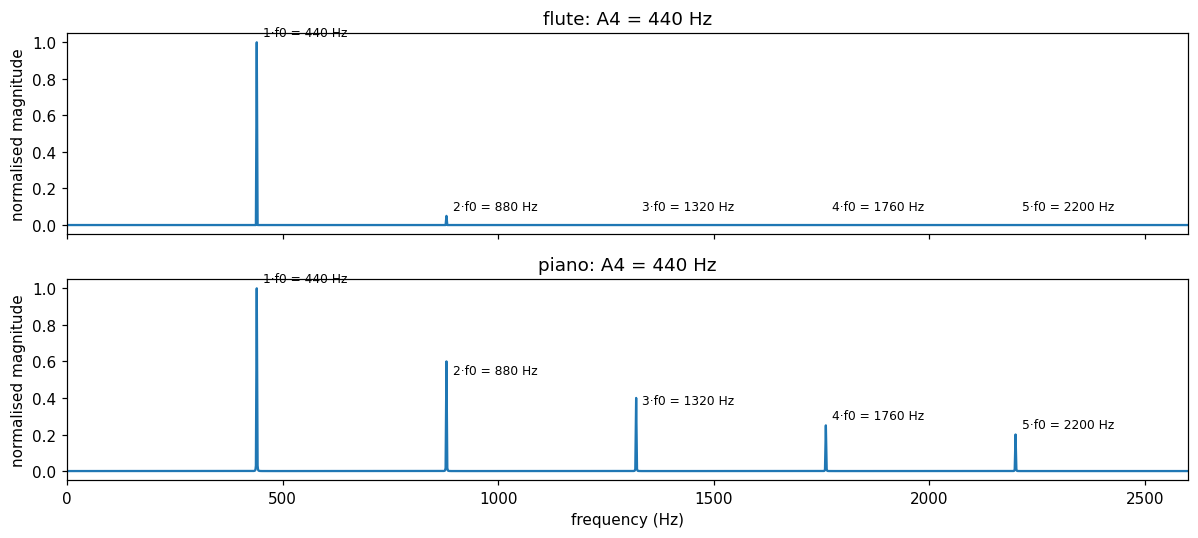

In [2]:
sr = features.SR
a4 = librosa.note_to_midi("A4")
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for ax, timbre in zip(axes, ["flute", "piano"]):
    note = synth.render_note(a4, 1.0, sr, timbre=timbre, amp=0.8)
    spec = np.abs(np.fft.rfft(note * np.hanning(len(note))))
    freqs = np.fft.rfftfreq(len(note), 1 / sr)
    ax.plot(freqs, spec / spec.max())
    ax.set_xlim(0, 2600); ax.set_ylabel("normalised magnitude"); ax.set_title(f"{timbre}: A4 = 440 Hz")
    for k in range(1, 6):
        ax.annotate(f"{k}·f0 = {440 * k} Hz", (440 * k, 1.0 / k if timbre == 'piano' else (1.0 if k == 1 else 0.05)),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)
axes[1].set_xlabel("frequency (Hz)")
plt.tight_layout(); plt.show()

## 3.2 Why overtones make chord recognition hard

The paper lists three difficulties. Each one can be *seen* on a chroma vector — the 12-dimensional pitch-class profile we build in notebook 4. Here is the most surprising one, **false positives**: the overtones of a *single* note land on other pitch classes. For A: $2f_0$ is A again, $3f_0$ is E (a fifth up), $4f_0$ is A, $5f_0$ is C♯ (a major third). So one piano note looks a lot like an A-major triad.

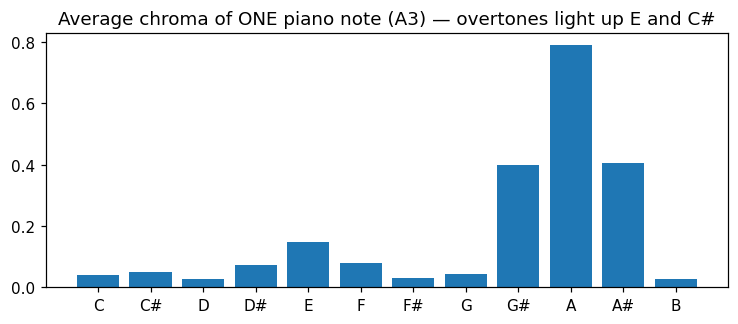

A template matcher would call this single note: A:maj


In [3]:
note = synth.render_note(librosa.note_to_midi("A3"), 2.0, sr, timbre="piano", amp=0.8)
chroma, times = features.cqt_chroma(note, sr)
profile = chroma.mean(axis=1)
states, sim = templates.template_decode(chroma)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(templates.PITCH_CLASSES, profile)
ax.set_title("Average chroma of ONE piano note (A3) — overtones light up E and C#")
plt.show()
winner = templates.CHORD_LABELS[np.bincount(states, minlength=24).argmax()]
print("A template matcher would call this single note:", winner)

The other two difficulties — **spectral crowding** (overlapping harmonics of different notes fill each other's bins) and **root pitch isolation** (the root is often not the loudest component, or not played at all) — are the reason the paper spends effort on the *frequency resolution* of the front end.

## 3.3 The STFT and its fixed window (Eq. 5)

$$ X_\text{STFT}[m, k] = \sum_{n=0}^{N-1} x[n]\, w[n - mH]\, e^{-j 2\pi k n / N} \qquad (5) $$

One window length $N$ for all frequencies means one frequency resolution $\Delta f = F_s / N$ everywhere. That is fine at 2 kHz, where semitones are ~120 Hz apart, and disastrous at 65 Hz, where C2 and C♯2 are only 3.9 Hz apart. Let us play two very low notes together and look at both transforms.

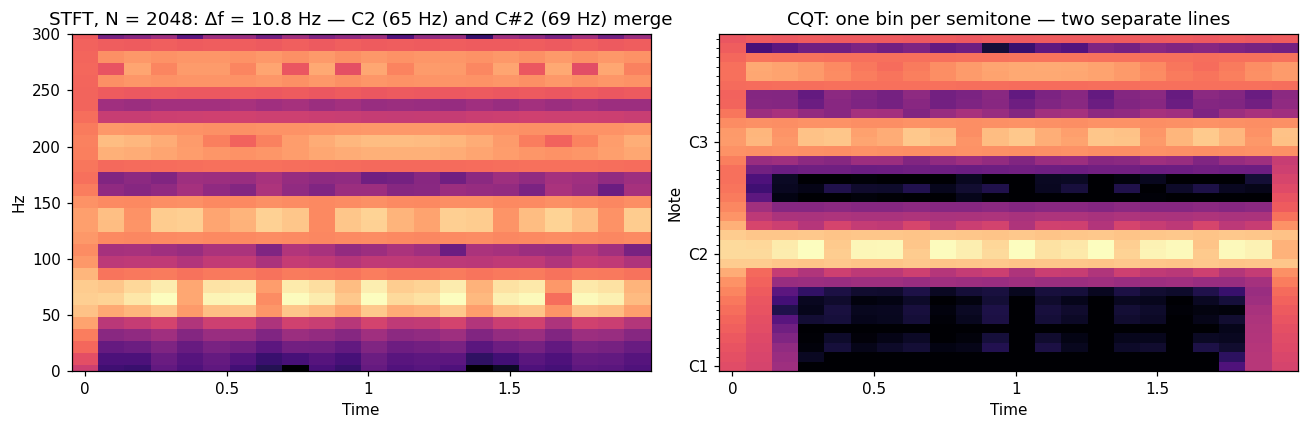

In [4]:
low = synth.render_note(librosa.note_to_midi("C2"), 2.0, sr, "organ", 0.5) + synth.render_note(librosa.note_to_midi("C#2"), 2.0, sr, "organ", 0.5)
n_fft = 2048
S = np.abs(librosa.stft(low, n_fft=n_fft, hop_length=features.HOP_LENGTH))
C = np.abs(features.cqt(low, sr, n_bins=36))          # three octaves from C1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
librosa.display.specshow(librosa.amplitude_to_db(S, ref=np.max), sr=sr, hop_length=features.HOP_LENGTH, y_axis="linear", x_axis="time", ax=axes[0])
axes[0].set_ylim(0, 300); axes[0].set_title(f"STFT, N = {n_fft}: Δf = {sr / n_fft:.1f} Hz — C2 (65 Hz) and C#2 (69 Hz) merge")
librosa.display.specshow(librosa.amplitude_to_db(C, ref=np.max), sr=sr, hop_length=features.HOP_LENGTH, y_axis="cqt_note", x_axis="time", fmin=features.FMIN, ax=axes[1])
axes[1].set_title("CQT: one bin per semitone — two separate lines")
plt.tight_layout(); plt.show()

## 3.4 The Constant-Q Transform (Eqs. 6–9)

The CQT (Brown, 1991) places bins **logarithmically**, exactly on the 12-TET grid, and gives each bin a window whose length is inversely proportional to its centre frequency:

$$ X_\text{CQT}[m, k] = \frac{1}{N_k} \sum_{n=0}^{N_k - 1} x[n]\, w_k[n]\, e^{-j 2\pi Q n / N_k} \qquad (6) $$
$$ N_k = Q \cdot \frac{F_s}{f_k} \qquad (7) \qquad\qquad f_k = f_\min \cdot 2^{k/12} \qquad (8) $$
$$ Q = \frac{f_k}{\delta f_k} = \frac{f_k}{f_{k+1} - f_k} = \left(2^{1/12} - 1\right)^{-1} \qquad (9) $$

$Q$ is the ratio of a bin's centre frequency to its bandwidth, and it is the same for every bin — hence *constant Q*. Let us evaluate Eq. 9 and Eqs. 7–8 numerically.

Eq. (9): Q = 1 / (2^(1/12) - 1) = 16.8172
   (the paper prints ≈ 17.034; the exact value is 16.82 — 17 is the usual rounded figure in the CQT literature)
f_min = C1 = 32.70 Hz, 84 bins = 7 octaves, top bin ≈ 3951 Hz


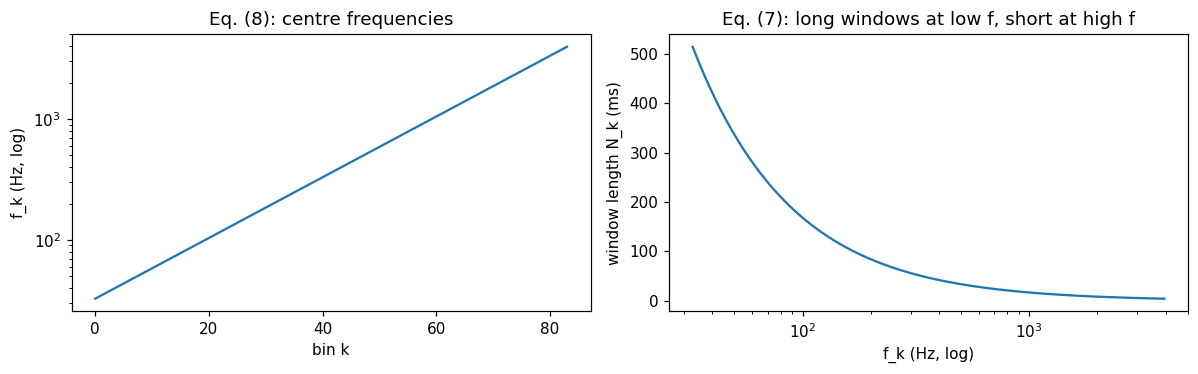

window at C1: 514 ms (11339 samples);  window at B7: 4.3 ms (94 samples)


In [5]:
print(f"Eq. (9): Q = 1 / (2^(1/12) - 1) = {features.Q_FACTOR:.4f}")
print("   (the paper prints ≈ 17.034; the exact value is 16.82 — 17 is the usual rounded figure in the CQT literature)")
print(f"f_min = C1 = {features.FMIN:.2f} Hz, {features.N_BINS} bins = {features.N_OCTAVES} octaves, top bin ≈ {features.cqt_center_frequencies()[-1]:.0f} Hz")

fk = features.cqt_center_frequencies()
Nk = features.cqt_window_lengths()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].semilogy(fk); ax[0].set(xlabel="bin k", ylabel="f_k (Hz, log)", title="Eq. (8): centre frequencies")
ax[1].plot(fk, Nk / sr * 1000); ax[1].set_xscale("log"); ax[1].set(xlabel="f_k (Hz, log)", ylabel="window length N_k (ms)", title="Eq. (7): long windows at low f, short at high f")
plt.tight_layout(); plt.show()
print(f"window at C1: {Nk[0] / sr * 1000:.0f} ms ({Nk[0]:.0f} samples);  window at B7: {Nk[-1] / sr * 1000:.1f} ms ({Nk[-1]:.0f} samples)")

## 3.5 Fig. 2: two ways to tile the time–frequency plane

The STFT tiles the plane with identical rectangles; the CQT with rectangles that get *wider in frequency and shorter in time* as frequency rises. That is precisely what music needs: low notes are close together in Hertz and change slowly, high notes are far apart and can change fast.

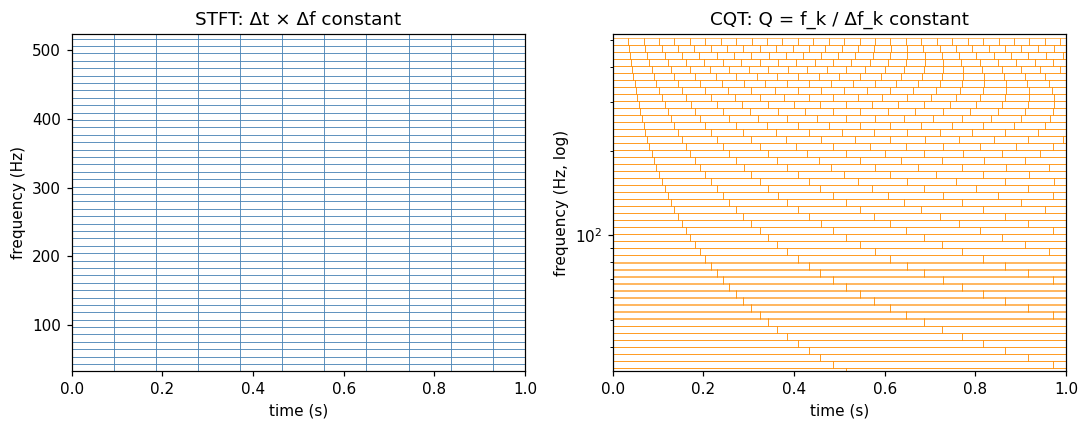

In [6]:
plots.plot_tf_tiling(sr=sr, fmin=features.FMIN, n_octaves=4, n_fft=2048)
plt.tight_layout(); plt.show()

## 3.6 The CQT of the toy progression

Finally the full CQT (7 octaves, 84 bins) of our toy piano progression, with the chord boundaries overlaid. Look for the repeated *stripes* an octave apart — those are the overtones we will fold together in the next notebook.

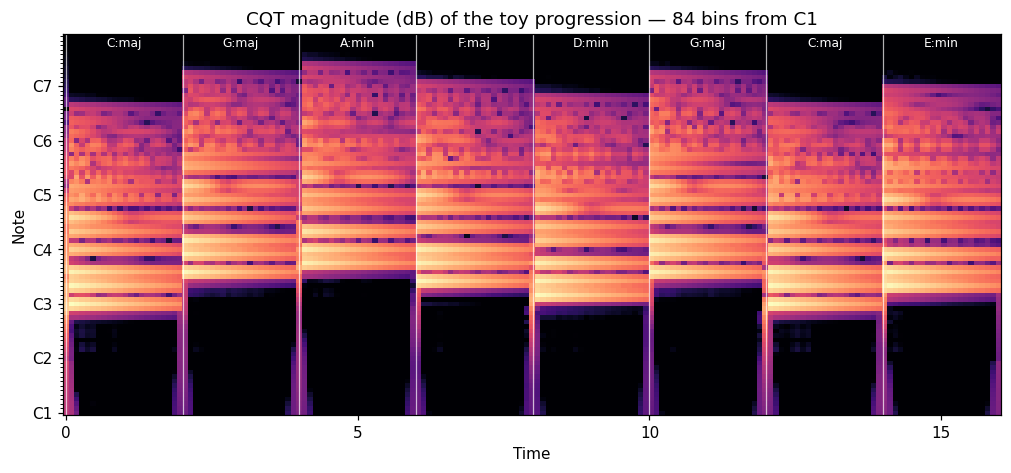

CQT shape (bins, frames): (84, 173)


In [7]:
y, gt_intervals, gt_labels = synth.render_progression(synth.DEMO_PROGRESSION, 2.0, sr, timbre="piano")
C = features.cqt(y, sr)
fig, ax = plt.subplots(figsize=(11, 4.5))
librosa.display.specshow(librosa.amplitude_to_db(np.abs(C), ref=np.max), sr=sr, hop_length=features.HOP_LENGTH, y_axis="cqt_note", x_axis="time", fmin=features.FMIN, ax=ax)
plots.overlay_segments(ax, gt_intervals, gt_labels, y=ax.get_ylim()[1] * 0.97, color="w")
ax.set_title("CQT magnitude (dB) of the toy progression — 84 bins from C1")
plt.show()
print("CQT shape (bins, frames):", C.shape)

## Exercises

1. Re-run section 3.3 with `n_fft = 8192`. Does the STFT now resolve C2 from C♯2? What happened to the time resolution (look at the frame count)?
2. Compute the CQT with `bins_per_octave=36` (three bins per semitone). Recompute $Q$ and $N_k$ for that setting by hand and check against `features.cqt_window_lengths(bins_per_octave=36)`.
3. The flute in Fig. 1 has a small second peak. Which overtone is it and which pitch class does it fall on?